# Extract Transmission Components from Far-Field Data

This notebook decomposes the far-field transmitted power through a local self-uniform disordered slab into three physically meaningful components:

1. **Ballistic transmission** $T_\text{ballistic}$ — coherent forward-scattered power that preserves both amplitude and phase of the reference beam.
2. **Co-polarized transmission** $T_\text{co}$ — total power projected onto the reference polarization state (includes the ballistic part).
3. **Cross-polarized transmission** $T_\text{cross}$ — scattered power orthogonal to the reference polarization.

The reference field $\mathbf{E}_\text{ref}(\theta, \varphi)$ is the far-field pattern of the incident beam propagating through free space (air), while $\mathbf{E}_\text{scat}(\theta, \varphi)$ is the far-field after passing through the disordered slab.

## 1. Imports and Configuration

Load tidy3d, numpy, matplotlib, and the custom `AutomationModule` helpers for HDF5 I/O, moving averages, etc.

In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys
import re

import numpy as np
import matplotlib.pyplot as plt
import tidy3d as td
from dotenv import load_dotenv

load_dotenv()

# Add parent project path so AutomationModule is importable
sys.path.append(os.path.abspath(rf'./'))
from AutomationModule import *
import AutomationModule as AM

tidy3dAPI = os.environ["API_TIDY3D_KEY"]

## 2. Define Data Paths

Paths to the HDF5 files containing:
- **Far-field data** from the photonic crystal slab simulation.
- **Reference far-field data** from the air-only (no slab) simulation.

In [2]:
field_folder = r"./data/20251006_far_field_eps_8p57_ff_21p72_air.h5"
ref_field_folder = r"./data/20251006_Ref_air_complete_field.h5"

## 3. Load Far-Field Data

Read both HDF5 files into nested dictionaries. Each contains the complex far-field components $E_\theta$, $E_\varphi$ sampled on a $(\theta, \varphi)$ grid, along with the frequency axis.

In [3]:
field_ref = AM.read_hdf5_as_dict(ref_field_folder)
field = AM.read_hdf5_as_dict(field_folder)

## 4. Transmission Decomposition Functions

### Solid-Angle Weighting

Each far-field sample covers a differential solid angle:

$$d\Omega = \sin\theta \, d\theta \, d\varphi$$

The weight for each $\theta$ bin is $w(\theta_i) = \sin\theta_i \, \Delta\theta_i$, computed via `np.gradient`.

### Co-polarized / Cross-polarized / Ballistic Decomposition

Given the reference far-field $\mathbf{E}_\text{ref} = (E_\theta^\text{ref},\, E_\varphi^\text{ref})$ and the scattered field $\mathbf{E}_\text{scat} = (E_\theta^\text{scat},\, E_\varphi^\text{scat})$ at each $(\theta, \varphi)$ direction:

**Co-polarized field** — projection of the scattered field onto the local reference polarization:

$$E_\text{co}(\theta,\varphi) = \frac{\mathbf{E}_\text{scat} \cdot \mathbf{E}_\text{ref}^*}{|\mathbf{E}_\text{ref}|}$$

**Co-polarized power** at each angular bin:

$$P_\text{co} = |E_\text{co}|^2$$

**Cross-polarized power** — the remainder orthogonal to the reference polarization:

$$P_\text{cross} = |\mathbf{E}_\text{scat}|^2 - P_\text{co}$$

**Integrated transmissions** (ratios normalized to the reference beam power):

$$T_\text{co} = \frac{\int P_\text{co}\, d\Omega}{\int P_\text{ref}\, d\Omega}, \qquad T_\text{cross} = \frac{\int P_\text{cross}\, d\Omega}{\int P_\text{ref}\, d\Omega}$$

**Ballistic (coherent) transmission** — measures how much of the transmitted beam is indistinguishable from the original reference in both amplitude *and* phase:

$$A = \frac{\int \mathbf{E}_\text{scat} \cdot \mathbf{E}_\text{ref}^*\, d\Omega}{\int |\mathbf{E}_\text{ref}|^2\, d\Omega}, \qquad T_\text{ballistic} = |A|^2$$

The angular integration is restricted to the cone $\theta \in [15°,\, 30°]$ to capture the optical aperture of the Cassegrain.

In [4]:
def solid_angle_weights(theta):
    """Compute per-bin solid-angle weights: w_i = sin(theta_i) * Delta_theta_i.
    The phi factor (Delta_phi) is multiplied externally."""
    return np.sin(theta) * np.gradient(theta)


def compute_transmission(
    E_theta_ref, E_phi_ref,    # shape (n_theta, n_phi, n_freq), complex — reference (air) far field
    E_theta_scat, E_phi_scat,  # same shape — scattered (slab) far field
    theta, phi                 # 1D arrays in radians
):
    """Decompose the far-field transmission into ballistic, co-polarized,
    and cross-polarized components over the angular cone theta in [15°, 30°].

    Returns arrays of shape (n_freq,) for T_ballistic, T_co, T_cross.
    """
    # --- Angular mask: restrict integration to theta in [15°, 30°] ---
    theta_deg = theta * 180 / np.pi
    theta_mask = np.where((theta_deg >= 15) & (theta_deg <= 30))[0]

    # --- Build 2-D solid-angle weight grid: W(theta, phi) = sin(theta)*dtheta*dphi ---
    dphi = np.diff(phi)[1]                              # uniform phi spacing
    w_theta = solid_angle_weights(theta[theta_mask])    # shape (n_theta_masked,)
    W = np.outer(w_theta, np.ones_like(phi)) * dphi     # shape (n_theta_masked, n_phi)

    nfreq = E_theta_ref.shape[-1] if E_theta_ref is not None else E_phi_ref.shape[-1]
    T_ballistic = np.zeros(nfreq, dtype=float)
    T_co = np.zeros(nfreq, dtype=float)
    T_cross = np.zeros(nfreq, dtype=float)

    for k in range(nfreq):
        # Stack (E_theta, E_phi) into a 2-component vector at each angle — shape (nt, np, 2)
        Eref  = np.stack([E_theta_ref[theta_mask, :, k],  E_phi_ref[theta_mask, :, k]],  axis=-1)
        Escat = np.stack([E_theta_scat[theta_mask, :, k], E_phi_scat[theta_mask, :, k]], axis=-1)

        # Reference power per angular bin: P_ref = |E_ref|^2
        P_ref = np.sum(Eref * np.conj(Eref), axis=-1).real

        # Inner product E_scat · E_ref* (complex, used for projection)
        dot_scat_ref = np.sum(Escat * np.conj(Eref), axis=-1)

        # Avoid division by zero where the reference field is negligible
        mask = P_ref > 0
        sqrtPref = np.zeros_like(P_ref)
        sqrtPref[mask] = np.sqrt(P_ref[mask])

        # Co-polarized field: E_co = (E_scat · E_ref*) / |E_ref|
        E_co = np.zeros_like(dot_scat_ref)
        E_co[mask] = dot_scat_ref[mask] / sqrtPref[mask]
        P_co = np.abs(E_co)**2

        # Total scattered power
        P_scat = np.sum(Escat * np.conj(Escat), axis=-1).real

        # Cross-polarized power: P_cross = |E_scat|^2 - P_co
        P_cross = P_scat - P_co

        # --- Solid-angle integration ---
        T_co[k]    = np.sum(P_co    * W) / np.sum(P_ref * W)
        T_cross[k] = np.sum(P_cross * W) / np.sum(P_ref * W)

        # Ballistic: A = integral(E_scat·E_ref* dΩ) / integral(|E_ref|^2 dΩ), T_bal = |A|^2
        A = np.sum(dot_scat_ref * W) / np.sum(P_ref * W)
        T_ballistic[k] = np.abs(A)**2

    return T_ballistic, T_co, T_cross

## 5. Compute Transmission Components for All Slab Thicknesses

Loop over every thickness entry in the far-field data file, compute the three transmission components, and store them in a dictionary keyed by the entry name.

In [5]:
components_data = {}

for field_item in field.keys():
    print(field_item)

    T_ballistic, T_co, T_cross = compute_transmission(
        field_ref["Etheta"].squeeze(),
        field_ref["Ephi"].squeeze(),
        field[field_item]["Etheta"].squeeze(),
        field[field_item]["Ephi"].squeeze(),
        field_ref["theta_proj"],
        field_ref["phi_proj"],
    )

    components_data[field_item] = {
        "T_ballistic": T_ballistic,
        "T_co": T_co,
        "T_cross": T_cross,
    }

n_2.9275_ff_0.2172_size_0.34965034965034963
n_2.9275_ff_0.2172_size_0.6118881118881119
n_2.9275_ff_0.2172_size_0.6993006993006993
n_2.9275_ff_0.2172_size_0.7867132867132867
n_2.9275_ff_0.2172_size_0.8741258741258741
n_2.9275_ff_0.2172_size_1.0489510489510487
n_2.9275_ff_0.2172_size_1.2237762237762237


## 6. Photonic Bandgap Parameters

Define the bandgap edges (in reduced frequency units from MPB calculations) for the $n = 2.9$ rod structure and convert to wavelength ($\mu$m). The lattice constant is $a = 14.3 \times 0.8\;\mu\text{m}$.

In [6]:
# Bandgap edges in reduced frequency (a/λ) from MPB for n_rod = 2.9
gap_edges_freq = np.array([2.44619, 2.52278])

# Convert to wavelength: λ = a / (a/λ), with a = 14.3 * 0.8 μm
lattice_constant = 14.3 * 0.8  # μm
gap_edges  = lattice_constant / gap_edges_freq
gap_center = np.mean(gap_edges)
gap_width  = np.diff(gap_edges_freq)[0] / np.mean(gap_edges_freq)

print(f"Gap edges: {gap_edges} μm | Center: {gap_center:.3f} μm | Relative width: {gap_width:.4f}")

Gap edges: [4.67666044 4.53468   ] μm | Center: 4.606 μm | Relative width: 0.0308


## 7. Plot Results

Plot $T_\text{ballistic}$, $T_\text{co}$, and $T_\text{cross}$ vs. wavelength for each slab thickness. A moving-average smoothing window is applied and error bars show the standard error of the mean. The grey band marks the photonic bandgap region.

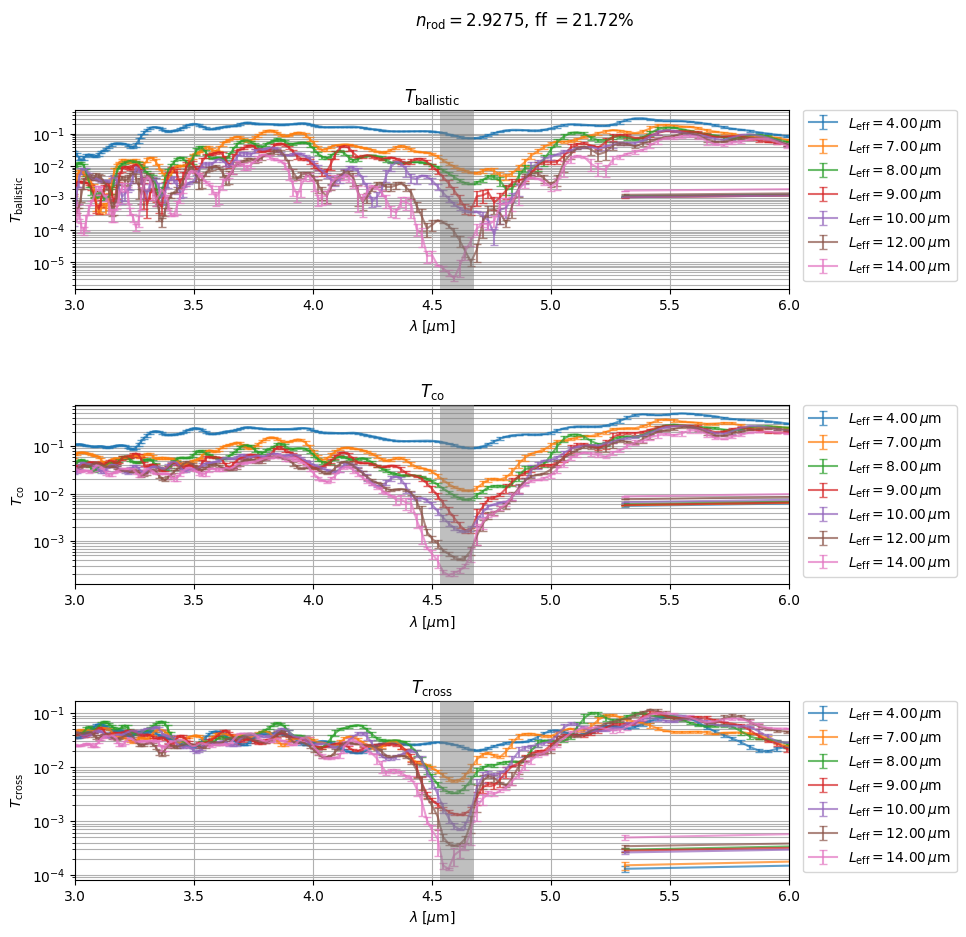

In [9]:
fig, ax = plt.subplots(ncols=1, nrows=3, figsize=(12, 10))
flatten_ax = ax.flatten()
titles = [r"$T_{\mathrm{ballistic}}$", r"$T_{\mathrm{co}}$", r"$T_{\mathrm{cross}}$"]
component_keys = ["T_ballistic", "T_co", "T_cross"]
window = 3  # moving-average smoothing window

# Smoothed wavelength axis (same for all entries)
lambda_smooth = AM.moving_average(td.C_0 / field_ref["freqs"], window)

for element in components_data.keys():
    # Extract effective slab thickness from the key name and scale to μm
    size = float(re.search(r'size_([+-]?\d+(?:\.\d+)?)', element).group(1)) * lattice_constant

    for i, key in enumerate(component_keys):
        y_smooth, y_err = AM.moving_average_with_sem(components_data[element][key], window)
        flatten_ax[i].errorbar(
            lambda_smooth, y_smooth, yerr=y_err,
            label=rf"$L_{{\mathrm{{eff}}}}={size:.2f}\,\mu\mathrm{{m}}$",
            capsize=3, alpha=0.7,
        )

# Add bandgap shading and format each subplot
for i, a in enumerate(flatten_ax):
    a.axvspan(gap_edges[0], gap_edges[1], facecolor='gray', alpha=0.5, edgecolor='none', zorder=1000)
    a.set_yscale('log')
    a.set_xlim(3, 6)
    a.grid(visible=True, which="both")
    a.set_ylabel(titles[i])
    a.set_xlabel(r"$\lambda\;[\mu\mathrm{m}]$")
    a.set_title(titles[i])
    a.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)

fig.subplots_adjust(right=0.72)
plt.suptitle(r"$n_{\mathrm{rod}}=2.9275$, ff $= 21.72\%$")
plt.subplots_adjust(hspace=0.65)
plt.show()